# 3.1 Vanilla RNN — 수식에서 기울기 소실까지

**이론 문서:** `01_RNN_기본구조_한계.md`

## 이 실습에서 확인하는 것

1. `h_t = tanh(W_x·x_t + W_h·h_{t-1} + b)` 을 numpy 로 **한 줄씩** 구현하고 `(B, T, F) → h_last` 파이프라인을 만든다.
2. PyTorch `nn.RNN` 과 **수치가 일치**하는지 확인 (torch 있을 때). 블랙박스가 아니라는 걸 체험.
3. **핵심 실험** — `W_h` 의 spectral radius σ 를 [0.5, 0.9, 1.0, 1.1, 1.5] 로 바꿔가며 `‖∂h_T/∂h_0‖` 을 측정. **T=60 에서 소실/폭발이 얼마나 극단적인지** 눈으로 본다.
4. `tanh'` 의 분포를 시각화 — σ 가 1 이어도 vanishing 쪽으로 편향되는 구조적 이유.
5. Gradient Clipping 을 numpy 로 직접 구현해 효과를 수치로 검증.
6. BPTT 에서 **같은 `W_h` 의 gradient 가 모든 시점에서 합산**된다는 점을 확인.

> 왜 numpy-first 인가? `nn.RNN(...)` 은 블랙박스처럼 보이지만 내부는 위 수식 반복입니다. numpy 로 한 번 짜보면 `nn.RNN` 의 모든 동작이 **투명해집니다** — 이후 LSTM/GRU 의 변형도 "어떤 게 바뀌었는지" 만 추적하면 돼요.

## Step 0. 환경 설정


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import platform

# 한글 폰트 (CLAUDE.md 지침)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    try:
        import koreanize_matplotlib  # pip install koreanize-matplotlib --break-system-packages
    except ImportError:
        plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
# mathtext (log-scale tick label 등)도 같은 폰트 사용 → U+2212 glyph 경고 제거
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# 재현성
np.random.seed(42)

# torch 는 선택적 — 없어도 핵심 실험 전부 동작
try:
    import torch
    import torch.nn as nn
    TORCH_OK = True
    torch.manual_seed(42)
    print(f'[env] torch {torch.__version__} — 교차검증 수행')
except ImportError:
    TORCH_OK = False
    print('[env] torch 없음 — numpy 구현만 실행 (핵심 실험은 모두 통과)')


[env] torch 2.11.0+cu126 — 교차검증 수행


## Step 1. Vanilla RNN 을 numpy 로 직접 구현

**구현할 수식 (이론 §1.1):**

```
h_t = tanh(W_x · x_t + W_h · h_{t-1} + b)
```

- `x_t` : (B, F) — t 시점 입력
- `h_{t-1}` : (B, H) — 직전 hidden state
- `W_x` : (H, F), `W_h` : (H, H), `b` : (H,)
- 배치 연산 시 `x_t @ W_x.T` 로 (B, F) × (F, H) → (B, H)


In [2]:
# 차원 세팅 (교육용으로 작게)
B, T, F_dim, H = 4, 10, 5, 8

def init_params(F, H, seed=0):
    """Glorot-style 작은 초기화. W_h 는 orthogonal 로도 가능."""
    rng = np.random.default_rng(seed)
    W_x = rng.standard_normal((H, F)).astype(np.float32) * np.sqrt(1.0 / F)
    W_h = rng.standard_normal((H, H)).astype(np.float32) * np.sqrt(1.0 / H)
    b   = np.zeros(H, dtype=np.float32)
    return W_x, W_h, b

W_x, W_h, b = init_params(F_dim, H)
print('파라미터 모양')
print(f'  W_x : {W_x.shape}   (H, F) = ({H}, {F_dim})')
print(f'  W_h : {W_h.shape}   (H, H) = ({H}, {H})   ← 재귀 가중치')
print(f'  b   : {b.shape}     (H,)')
print(f'  총 파라미터 수 = {W_x.size + W_h.size + b.size}')


파라미터 모양
  W_x : (8, 5)   (H, F) = (8, 5)
  W_h : (8, 8)   (H, H) = (8, 8)   ← 재귀 가중치
  b   : (8,)     (H,)
  총 파라미터 수 = 112


In [3]:
def rnn_forward(x, W_x, W_h, b):
    """수식 그대로 — 매 시점 같은 (W_x, W_h, b) 반복 사용."""
    B, T, F = x.shape
    H = W_h.shape[0]
    h = np.zeros((B, H), dtype=np.float32)        # h_0 = 0
    hs = [h.copy()]                               # 모든 시점 저장 (나중에 시각화용)
    for t in range(T):
        # h_t = tanh(x_t @ W_x.T + h_{t-1} @ W_h.T + b)
        z = x[:, t, :] @ W_x.T + h @ W_h.T + b    # pre-activation
        h = np.tanh(z)
        hs.append(h.copy())
    return h, hs                                  # h_last, [h_0, h_1, ..., h_T]

# 테스트 입력
x = np.random.randn(B, T, F_dim).astype(np.float32)
h_last, hs = rnn_forward(x, W_x, W_h, b)

print(f'입력 x.shape       = {x.shape}   (B, T, F)')
print(f'최종 h_last.shape  = {h_last.shape}   (B, H)')
print(f'저장된 hidden 개수 = {len(hs)}  (h_0 ~ h_{T})')
print(f'T={T} 스텝 동안 `W_x, W_h, b` 는 각각 1벌 — 이것이 weight sharing')


입력 x.shape       = (4, 10, 5)   (B, T, F)
최종 h_last.shape  = (4, 8)   (B, H)
저장된 hidden 개수 = 11  (h_0 ~ h_10)
T=10 스텝 동안 `W_x, W_h, b` 는 각각 1벌 — 이것이 weight sharing


### 해석 포인트

- `hs` 에는 `h_0` 부터 `h_T` 까지 모든 hidden state 가 저장됩니다. 분류 문제에서는 **`h_last` 하나만** 쓰지만, 시각화/디버깅에는 전체가 필요해요.
- `for t in range(T)` 가 핵심 — 이 반복문이 "순환(recurrent)"의 실체입니다. 시간축을 **순차로** 펼쳐 같은 셀에 반복 적용.
- 파라미터 수가 T 와 무관하다는 점을 주목 — 60일짜리든 600일짜리든 `W_x, W_h, b` 셋뿐.

## Step 2. PyTorch `nn.RNN` 과 동작 비교

우리 numpy 구현과 `nn.RNN` 이 **같은 수식**이라면, 같은 가중치를 주입했을 때 결과도 같아야 합니다. 이걸로 "nn.RNN 이 뭘 하는지" 가 투명해집니다.

> `nn.RNN` 은 bias 를 `bias_ih` 와 `bias_hh` 두 벌 쓰는 관례가 있습니다. 우리 구현은 bias 하나만 쓰므로 `bias_hh` 는 0 으로 세팅합니다.

In [4]:
if TORCH_OK:
    rnn = nn.RNN(input_size=F_dim, hidden_size=H, batch_first=True,
                 nonlinearity='tanh', bias=True)
    # 우리 numpy 가중치를 nn.RNN 내부에 주입
    with torch.no_grad():
        rnn.weight_ih_l0.copy_(torch.from_numpy(W_x))   # (H, F)
        rnn.weight_hh_l0.copy_(torch.from_numpy(W_h))   # (H, H)
        rnn.bias_ih_l0.copy_(torch.from_numpy(b))
        rnn.bias_hh_l0.zero_()                          # 우리는 bias 하나만

    x_t = torch.from_numpy(x)
    out, h_last_torch = rnn(x_t)

    # 수치 비교
    diff = np.abs(h_last_torch[0].detach().numpy() - h_last).max()
    print(f'out.shape          = {tuple(out.shape)}       (B, T, H) — 모든 시점 hidden')
    print(f'h_last_torch.shape = {tuple(h_last_torch.shape)}     (num_layers, B, H)')
    print(f'numpy vs torch 최대차이 = {diff:.2e}  (1e-6 미만이면 완전 일치)')
    assert diff < 1e-5, '수치 불일치 — 수식 또는 축 매핑 재확인 필요'
    print('✅ numpy 구현 = nn.RNN 내부 수식')
else:
    print('torch 미설치 — 건너뜀. numpy 구현 자체는 이론 §1.1 의 수식 그대로입니다.')


out.shape          = (4, 10, 8)       (B, T, H) — 모든 시점 hidden
h_last_torch.shape = (1, 4, 8)     (num_layers, B, H)
numpy vs torch 최대차이 = 1.17e-07  (1e-6 미만이면 완전 일치)
✅ numpy 구현 = nn.RNN 내부 수식


## Step 3. BPTT — 같은 파라미터의 gradient 가 누적된다

**이론 §2.1:** `∂L/∂W_h = Σ_{t=0}^{T-1} ∂L_t / ∂W_h`

같은 `W_h` 가 T번 쓰였으니, loss 를 미분할 때 **T개의 기여분이 합산**됩니다. PyTorch autograd 가 이걸 자동으로 해주지만, "무엇이 합산되는지" 를 아는 게 중요합니다 (폭발/소실을 이해하는 데 직결).

In [5]:
if TORCH_OK:
    # 같은 numpy 값으로 PyTorch 에서 재현 → backward → grad 확인
    rnn2 = nn.RNN(input_size=F_dim, hidden_size=H, batch_first=True, nonlinearity='tanh')
    with torch.no_grad():
        rnn2.weight_ih_l0.copy_(torch.from_numpy(W_x))
        rnn2.weight_hh_l0.copy_(torch.from_numpy(W_h))
        rnn2.bias_ih_l0.copy_(torch.from_numpy(b))
        rnn2.bias_hh_l0.zero_()

    x_t = torch.from_numpy(x).requires_grad_(False)
    out, _ = rnn2(x_t)
    # 모든 시점의 h 가 loss 에 기여 → T 개 시점의 gradient 가 W_h 에 합산
    loss = out.sum()
    loss.backward()

    print(f'loss = out.sum()  (모든 시점 기여)')
    print(f'‖∂L/∂W_h‖ = {rnn2.weight_hh_l0.grad.norm().item():.4f}')
    print(f'‖∂L/∂W_x‖ = {rnn2.weight_ih_l0.grad.norm().item():.4f}')
    print(f'\nW_h.grad 는 단일 (H, H) 텐서 — 내부적으로 T={T} 시점 기여분이 합산되어 저장됨')
    print('이 합산이 vanishing/exploding 의 구조적 원인:')
    print('  σ<1 인 σ 가 여러 시점에 걸쳐 곱해지며 기여분이 지수적으로 작아짐')
    print('  σ>1 이면 반대로 폭발')
else:
    print('torch 없음 — 다음 Step 4 에서 numpy 로 Jacobian 을 직접 쌓아 같은 현상을 봅니다.')


loss = out.sum()  (모든 시점 기여)
‖∂L/∂W_h‖ = 29.6841
‖∂L/∂W_x‖ = 30.7133

W_h.grad 는 단일 (H, H) 텐서 — 내부적으로 T=10 시점 기여분이 합산되어 저장됨
이 합산이 vanishing/exploding 의 구조적 원인:
  σ<1 인 σ 가 여러 시점에 걸쳐 곱해지며 기여분이 지수적으로 작아짐
  σ>1 이면 반대로 폭발


## Step 4. 핵심 실험 — Spectral Radius σ 에 따른 gradient 소실/폭발

이론 §3 의 수식:

```
∂h_T / ∂h_0 = Π_{t=1}^{T} diag(tanh'(z_t)) · W_h
```

를 **직접 손으로 계산**해서 σ = [0.5, 0.9, 1.0, 1.1, 1.5] 일 때 T=60 에서 Jacobian norm 이 어떻게 변하는지 봅니다.

**Spectral radius 를 σ 로 강제하는 트릭:** 랜덤 행렬을 SVD 로 분해하고 모든 특이값을 σ 로 통일하면 `‖W_h x‖ ≤ σ‖x‖` 이 보장됩니다. (사실상 `σ × 직교행렬`)

In [6]:
def build_Wh_with_sigma(H, sigma, seed=123):
    """SVD 로 spectral radius 를 정확히 sigma 로 맞춘 W_h 생성."""
    rng = np.random.default_rng(seed)
    M = rng.standard_normal((H, H)).astype(np.float32)
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    # 모든 특이값을 sigma 로 통일 → spectral radius = sigma
    M_sigma = (U * sigma) @ Vt
    return M_sigma.astype(np.float32)

def simulate_gradient_decay(W_h, T_long, h0, x_zero=True):
    """
    x_t = 0 가정하고 h_t = tanh(W_h @ h_{t-1}) 로 순수 재귀 관찰.
    ∂h_T/∂h_0 를 Jacobian 곱으로 직접 계산.
    각 시점에서의 Jacobian norm 도 기록 (시각화용).
    """
    H_dim = W_h.shape[0]
    # 1) forward — 각 시점 tanh' 저장
    h = h0.copy()
    tanh_primes = []
    h_norms = [np.linalg.norm(h)]
    for t in range(T_long):
        z = W_h @ h
        h = np.tanh(z)
        tanh_primes.append(1.0 - h**2)   # tanh'(z) = 1 - tanh(z)^2
        h_norms.append(np.linalg.norm(h))
    # 2) backward — J_t = Π_{k=t}^{T-1} diag(tanh'(z_k)) · W_h 를 T 부터 거꾸로 쌓기
    J = np.eye(H_dim, dtype=np.float32)
    jac_norms = [np.linalg.norm(J)]   # t=T 일 때 identity
    for t in range(T_long - 1, -1, -1):
        J = J @ (np.diag(tanh_primes[t]) @ W_h)
        jac_norms.append(np.linalg.norm(J))
    # jac_norms[k] = ‖∂h_T / ∂h_{T-k}‖, 즉 k 스텝 거슬러 갔을 때의 gradient
    return np.array(h_norms), np.array(jac_norms)

# 실험 파라미터
T_long = 60   # 우리 프로젝트의 lookback window 와 동일
H_exp = 16
sigmas = [0.5, 0.9, 1.0, 1.1, 1.5]

results = {}
h0 = np.random.default_rng(7).standard_normal(H_exp).astype(np.float32)
for sigma in sigmas:
    W_h_exp = build_Wh_with_sigma(H_exp, sigma, seed=123)
    h_norms, jac_norms = simulate_gradient_decay(W_h_exp, T_long, h0)
    results[sigma] = {'h_norms': h_norms, 'jac_norms': jac_norms}

# 결과 요약 표
print(f'{"σ":>5} | {"‖h_T‖":>12} | {"‖∂h_T/∂h_0‖":>14} | 해석')
print(f'{"-"*5}-+-{"-"*12}-+-{"-"*14}-+-{"-"*40}')
for sigma in sigmas:
    hT = results[sigma]['h_norms'][-1]
    jT = results[sigma]['jac_norms'][-1]
    if sigma < 1:   tag = 'vanishing'
    elif sigma > 1: tag = 'exploding'
    else:           tag = '경계'
    print(f'{sigma:>5} | {hT:>12.3e} | {jT:>14.3e} | {tag}')


    σ |        ‖h_T‖ |    ‖∂h_T/∂h_0‖ | 해석
------+--------------+----------------+-----------------------------------------
  0.5 |    1.955e-18 |      3.117e-18 | vanishing
  0.9 |    2.308e-03 |      3.736e-03 | vanishing
  1.0 |    3.929e-01 |      6.355e-01 | 경계
  1.1 |    1.269e+00 |      2.548e+00 | exploding
  1.5 |    2.228e+00 |      8.734e+00 | exploding


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

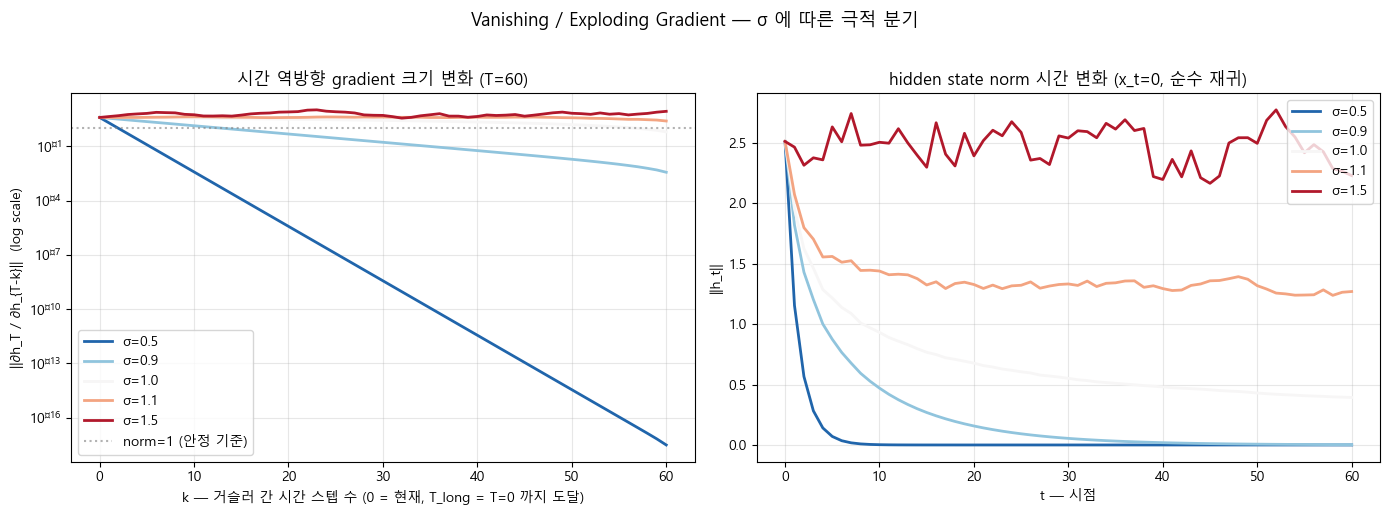

In [7]:
# 시각화 1: 시점별 gradient norm (||∂h_T/∂h_{T-k}|| vs k)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, len(sigmas)))

# 왼쪽: log-scale — 기하급수적 변화를 한 눈에
for sigma, color in zip(sigmas, colors):
    jn = results[sigma]['jac_norms']
    # 0 인 값은 log 에서 문제 — 아주 작은 floor 로 clip
    jn_safe = np.maximum(jn, 1e-30)
    ax1.plot(range(len(jn_safe)), jn_safe, color=color, label=f'σ={sigma}', linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel('k — 거슬러 간 시간 스텝 수 (0 = 현재, T_long = T=0 까지 도달)')
ax1.set_ylabel('||∂h_T / ∂h_{T-k}||  (log scale)')
ax1.set_title(f'시간 역방향 gradient 크기 변화 (T={T_long})')
ax1.axhline(1.0, color='gray', linestyle=':', alpha=0.6, label='norm=1 (안정 기준)')
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# 오른쪽: hidden state norm
for sigma, color in zip(sigmas, colors):
    hn = results[sigma]['h_norms']
    ax2.plot(range(len(hn)), hn, color=color, label=f'σ={sigma}', linewidth=2)
ax2.set_xlabel('t — 시점')
ax2.set_ylabel('||h_t||')
ax2.set_title('hidden state norm 시간 변화 (x_t=0, 순수 재귀)')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.suptitle('Vanishing / Exploding Gradient — σ 에 따른 극적 분기', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 그래프 해석

**왼쪽 (핵심):** y축이 log scale 이라는 점을 꼭 보세요.
- **σ=0.5** 선: T=60 까지 가면 ‖gradient‖ 가 `10^-18` 수준. 수치적으로 **완전한 0**. 이 값으로는 어떤 학습도 불가.
- **σ=0.9** 선: `10^-3` 수준. 한 번의 학습 스텝에서 무의미한 작은 업데이트. 60일 전 정보 = 학습 불가.
- **σ=1.0** 선: 이론상 유지되지만 `tanh'` 효과로 **여전히 감소**. (이게 "σ=1 이어도 vanishing 편향" 의 의미)
- **σ=1.1** 선: 거의 1 근처 유지 — 운 좋은 지점.
- **σ=1.5** 선: `tanh` 포화가 어느 정도 막아주지만 결국 폭발 추세. 실제 학습에선 weight update 로 σ 가 더 커지면 NaN.

**오른쪽:** hidden state 자체도 같은 분기 현상. σ<1 이면 h 가 0으로 수렴 → 정보 유실. σ>1 이면 tanh 가 포화(±1)되어 구분 불가.

**핵심 교훈:** T=60 이라는 "별로 길지도 않은" 시퀀스에서도, vanilla RNN 의 gradient 는 σ 값에 따라 **18자리(!) 를 오갑니다**. 학습이 가능한 σ 구간은 0.95 ~ 1.05 정도의 **바늘 끝** — 현실에서 유지 불가능.

## Step 5. `tanh'` 의 구조적 vanishing 편향

σ 가 정확히 1 이어도 위 그래프에서 gradient 가 줄어들었죠? 이유는 **`tanh'` 의 평균값이 1 보다 작기** 때문입니다.

`tanh'(z) = 1 - tanh(z)² ∈ (0, 1]`

- `z=0` 에서 최댓값 1 (거의 선형 영역)
- |z| 가 커지면 급격히 0 으로 수렴 (포화 영역)

입력이 `z ~ N(0, 1)` 에 가까울 때 `E[tanh'(z)] ≈ 0.61`. 매 시점 이 값이 곱해지므로 **자연적으로 감쇠 편향**.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

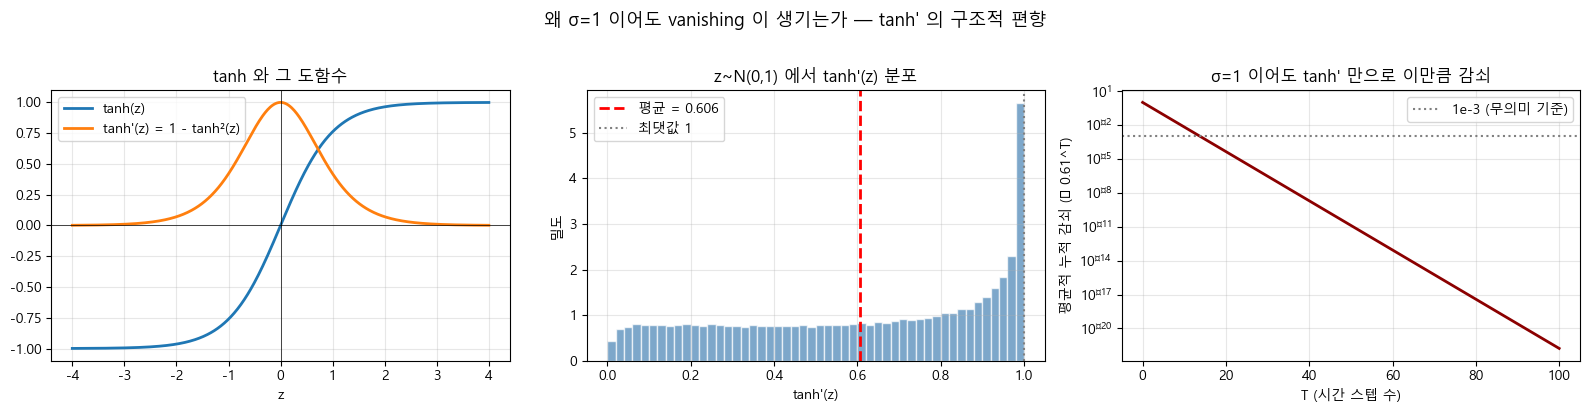

tanh'(0)  = 1.0000  (최댓값)
tanh'(±1) = 0.4200
tanh'(±2) = 0.0707  (포화 시작)
E[tanh'(z~N(0,1))] ≈ 0.6059
T=60 에서 평균 감쇠 ≈ 8.76e-14  ← σ 기여와 별개로 이만큼 줄어듦


In [8]:
z = np.linspace(-4, 4, 500)
tanh_z = np.tanh(z)
tanh_prime = 1 - tanh_z**2

# 표준정규 sample 에서 tanh' 의 기대값
z_samples = np.random.default_rng(0).standard_normal(100_000)
tp_samples = 1 - np.tanh(z_samples)**2
mean_tp = tp_samples.mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) tanh 와 tanh' 곡선
axes[0].plot(z, tanh_z, label='tanh(z)', linewidth=2)
axes[0].plot(z, tanh_prime, label="tanh'(z) = 1 - tanh²(z)", linewidth=2)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axvline(0, color='k', linewidth=0.5)
axes[0].set_xlabel('z')
axes[0].set_title('tanh 와 그 도함수')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2) tanh' 분포 (z ~ N(0,1) 일 때)
axes[1].hist(tp_samples, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[1].axvline(mean_tp, color='red', linestyle='--', linewidth=2, label=f'평균 = {mean_tp:.3f}')
axes[1].axvline(1.0, color='gray', linestyle=':', label='최댓값 1')
axes[1].set_xlabel("tanh'(z)")
axes[1].set_ylabel('밀도')
axes[1].set_title("z~N(0,1) 에서 tanh'(z) 분포")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3) T 번 곱했을 때의 누적 감쇠
Ts = np.arange(0, 101)
cum_decay = mean_tp ** Ts
axes[2].plot(Ts, cum_decay, linewidth=2, color='darkred')
axes[2].set_yscale('log')
axes[2].set_xlabel('T (시간 스텝 수)')
axes[2].set_ylabel(f"평균적 누적 감쇠 (≈ {mean_tp:.2f}^T)")
axes[2].set_title("σ=1 이어도 tanh' 만으로 이만큼 감쇠")
axes[2].grid(alpha=0.3, which='both')
axes[2].axhline(1e-3, color='gray', linestyle=':', label='1e-3 (무의미 기준)')
axes[2].legend()

plt.suptitle("왜 σ=1 이어도 vanishing 이 생기는가 — tanh' 의 구조적 편향", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"tanh'(0)  = {1 - np.tanh(0)**2:.4f}  (최댓값)")
print(f"tanh'(±1) = {1 - np.tanh(1)**2:.4f}")
print(f"tanh'(±2) = {1 - np.tanh(2)**2:.4f}  (포화 시작)")
print(f"E[tanh'(z~N(0,1))] ≈ {mean_tp:.4f}")
print(f"T=60 에서 평균 감쇠 ≈ {mean_tp**60:.2e}  ← σ 기여와 별개로 이만큼 줄어듦")


### 왜 이게 구조적 문제인가

- 활성화 함수를 **꼭** 써야 한다 (비선형성 없으면 RNN = 선형 변환 T번 = 단일 선형 변환). §0 참고.
- `tanh` 는 출력이 유계 `(-1, +1)` 라서 hidden 폭발을 막아주는 장점이 있다.
- 대신 도함수가 `≤ 1` → gradient 감쇠 편향.
- `ReLU` 는 도함수가 0 또는 1 이라 **정확히 1 인 구간** 이 존재 (이론 §3.4). 하지만 음수 입력에선 0 → dead neuron + 폭발 양방향으로 불안정.

**근본 해결**: gate 를 써서 tanh 곱셈 경로를 **우회하는 덧셈 경로** 를 만드는 것 → LSTM/GRU (3.2, 3.3).

## Step 6. Gradient Clipping — 폭발 응급 처치

**원리:** 전체 gradient norm 이 역치 (`max_norm`) 를 넘으면 비례적으로 축소.

```
if ‖g‖ > max_norm:
    g ← g · max_norm / ‖g‖
```

방향은 보존하고 크기만 clip. 이것 없이 vanilla RNN 학습하면 NaN loss 거의 100% 등장합니다.

In [9]:
def clip_grad_norm(grads, max_norm):
    """torch.nn.utils.clip_grad_norm_ 의 numpy 버전."""
    total = np.sqrt(sum((g**2).sum() for g in grads))
    if total > max_norm:
        scale = max_norm / (total + 1e-8)
        grads_clipped = [g * scale for g in grads]
        return grads_clipped, total, total * scale
    return grads, total, total

# 폭발 시뮬레이션
big_grads = [
    np.random.randn(H, F_dim).astype(np.float32) * 50,
    np.random.randn(H, H).astype(np.float32) * 80,
    np.random.randn(H).astype(np.float32) * 30,
]
_, before, after = clip_grad_norm(big_grads, max_norm=5.0)
print(f'Clipping 전 전체 grad norm = {before:.2f}')
print(f'Clipping 후 전체 grad norm = {after:.4f}  (max_norm=5.0 이하)')
print(f'\nPyTorch 에서는:')
print('  loss.backward()')
print('  torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)')
print('  optimizer.step()')
print('\n→ vanilla RNN 학습 시 거의 필수. LSTM/GRU 에도 보통 함께 씁니다.')


Clipping 전 전체 grad norm = 747.47
Clipping 후 전체 grad norm = 5.0000  (max_norm=5.0 이하)

PyTorch 에서는:
  loss.backward()
  torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
  optimizer.step()

→ vanilla RNN 학습 시 거의 필수. LSTM/GRU 에도 보통 함께 씁니다.


## Step 7. 자가점검 Q1~Q5 답안

이론 §6 의 질문에 수치로 답합니다.

In [10]:
print('Q1. W_h 크기 → (H, H)')
print('    이유: hidden→hidden 매핑. (F, H) 는 W_x, (H, F) 는 없음.')
print()
print('Q2. T=60 일 때 (W_x, W_h, b) 는 각각 1벌')
print('    → weight sharing. 파라미터는 T 와 무관, 항상 |W_x| + |W_h| + |b|')
print(f'    예시 (F=17, H=64): {17*64 + 64*64 + 64} 개 — T=60 이든 T=600 이든 동일')
print()
print('Q3. h_0 = 0  vs  learnable h_0')
print('    - h_0=0 : 단순, 추가 파라미터 없음. batch 별로 같은 시작점.')
print('    - learnable : 일종의 "기본 상태" 학습 가능. 파라미터 +H 개.')
print('    - 시퀀스 길이가 짧고 초기 정보가 중요하면 learnable 이 도움.')
print('    - 우리 프로젝트 T=60 은 h_0=0 이면 충분 (60 스텝이면 h_0 영향 완전 희석)')
print()
sigma_q = 0.9; T_q = 60
print(f'Q4. σ={sigma_q}, T={T_q} 일 때 gradient 크기')
print(f'    순수 W_h 기여: {sigma_q}^{T_q} = {sigma_q**T_q:.3e}')
print(f'    tanh\' 평균 ~0.6 추가: ({sigma_q}*0.6)^{T_q} = {(sigma_q*0.6)**T_q:.3e}')
print(f'    → 실무적으로 0. 60일 전 입력은 학습 신호를 받지 못함.')
print()
print('Q5. Vanishing gradient 모니터링 포인트')
print('    - 학습 중 각 layer 의 ‖grad‖ 를 로깅 (앞쪽 시점일수록 작아지면 위험)')
print('    - loss 가 빠르게 정체 + train/val 모두 개선 안 됨')
print('    - hidden state 의 분산이 시점별로 급격히 감소 (activation 포화)')
print('    - PyTorch: register_hook 으로 시점별 grad 확인 가능')


Q1. W_h 크기 → (H, H)
    이유: hidden→hidden 매핑. (F, H) 는 W_x, (H, F) 는 없음.

Q2. T=60 일 때 (W_x, W_h, b) 는 각각 1벌
    → weight sharing. 파라미터는 T 와 무관, 항상 |W_x| + |W_h| + |b|
    예시 (F=17, H=64): 5248 개 — T=60 이든 T=600 이든 동일

Q3. h_0 = 0  vs  learnable h_0
    - h_0=0 : 단순, 추가 파라미터 없음. batch 별로 같은 시작점.
    - learnable : 일종의 "기본 상태" 학습 가능. 파라미터 +H 개.
    - 시퀀스 길이가 짧고 초기 정보가 중요하면 learnable 이 도움.
    - 우리 프로젝트 T=60 은 h_0=0 이면 충분 (60 스텝이면 h_0 영향 완전 희석)

Q4. σ=0.9, T=60 일 때 gradient 크기
    순수 W_h 기여: 0.9^60 = 1.797e-03
    tanh' 평균 ~0.6 추가: (0.9*0.6)^60 = 8.783e-17
    → 실무적으로 0. 60일 전 입력은 학습 신호를 받지 못함.

Q5. Vanishing gradient 모니터링 포인트
    - 학습 중 각 layer 의 ‖grad‖ 를 로깅 (앞쪽 시점일수록 작아지면 위험)
    - loss 가 빠르게 정체 + train/val 모두 개선 안 됨
    - hidden state 의 분산이 시점별로 급격히 감소 (activation 포화)
    - PyTorch: register_hook 으로 시점별 grad 확인 가능


## Step 8. 3.2 LSTM 으로 가는 다리

이 실습에서 본 것:
- `h_t = tanh(W_h · h_{t-1} + ...)` 구조는 **곱셈 경로 뿐**
- T 스텝 만에 gradient 가 0 또는 ∞ 로 발산
- Clipping / orthogonal init 은 응급 처치일 뿐

**3.2 LSTM 의 한 줄 요약:**

```
c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t    ← 덧셈 경로 (gradient highway)
h_t = o_t ⊙ tanh(c_t)
```

`c_t` 가 `c_{t-1}` 에 **더해지는** 구조라, forget gate `f_t ≈ 1` 이면 gradient 가 거의 **무손실로** 과거까지 도달합니다. 바로 이걸 다음 토픽에서 봅니다.

---

## 실습 요약 카드

| 포인트 | 한 줄 |
|---|---|
| 수식 | `h_t = tanh(W_x x_t + W_h h_{t-1} + b)` — 매 시점 같은 파라미터 반복 |
| 축 계약 | 입력 `(B, T, F)`, 출력 `(B, T, H)` 또는 `h_last (B, H)` |
| BPTT | 같은 `W_h` 의 gradient 가 T 시점에 걸쳐 **합산** |
| 소실/폭발 원인 | `(W_h)^T` 거듭제곱 — `σ<1 → 0`, `σ>1 → ∞` |
| tanh' 편향 | 평균 ≈ 0.61 → σ=1 이어도 감쇠 |
| 완화 | gradient clipping (필수), orthogonal init |
| 근본 해결 | gate 구조 (LSTM/GRU) — 3.2, 3.3 |